# Hiperparametrización de Algoritmos Genéticos con Algoritmos Genéticos
Este cuaderno muestra cómo usar un algoritmo genético para optimizar los hiperparámetros de otro GA aplicado al Problema del Viajante (TSP).

## Imports

In [1]:

import random
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy


## Definición del problema TSP

In [2]:

def generar_ciudades(n=20, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    return np.random.rand(n, 2)

def distancia(ciudad1, ciudad2):
    return np.linalg.norm(ciudad1 - ciudad2)

def distancia_total(ruta, ciudades):
    return sum(
        distancia(ciudades[ruta[i]], ciudades[ruta[(i+1)%len(ruta)]])
        for i in range(len(ruta))
    )

numero_ciudades = 20
ciudades = generar_ciudades(numero_ciudades)


## Algoritmo Genético base

In [3]:

def crear_individuo(n):
    ind = list(range(n))
    random.shuffle(ind)
    return ind

def poblacion_inicial(tam, n):
    return [crear_individuo(n) for _ in range(tam)]

def seleccion_torneo(poblacion, ciudades, k=3):
    candidatos = random.sample(poblacion, k)
    return min(candidatos, key=lambda r: distancia_total(r, ciudades))

def cruce_ox(p1, p2):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    hijo = [-1]*n
    hijo[a:b] = p1[a:b]
    pos = b
    for c in p2:
        if c not in hijo:
            if pos >= n:
                pos = 0
            hijo[pos] = c
            pos += 1
    return hijo

def mutacion_swap(ind, prob):
    if random.random() < prob:
        i, j = random.sample(range(len(ind)), 2)
        ind[i], ind[j] = ind[j], ind[i]
    return ind


## Ejecución del GA TSP

In [4]:

def ejecutar_ga_tsp(ciudades, tam_pob, p_cruce, p_mut, generaciones):
    poblacion = poblacion_inicial(tam_pob, len(ciudades))
    mejores = []

    for _ in range(generaciones):
        nueva = []
        while len(nueva) < tam_pob:
            p1 = seleccion_torneo(poblacion, ciudades)
            p2 = seleccion_torneo(poblacion, ciudades)
            hijo = cruce_ox(p1, p2) if random.random() < p_cruce else deepcopy(p1)
            hijo = mutacion_swap(hijo, p_mut)
            nueva.append(hijo)
        poblacion = nueva
        mejor = min(poblacion, key=lambda r: distancia_total(r, ciudades))
        mejores.append(distancia_total(mejor, ciudades))

    return mejores


## Visualización de convergencia

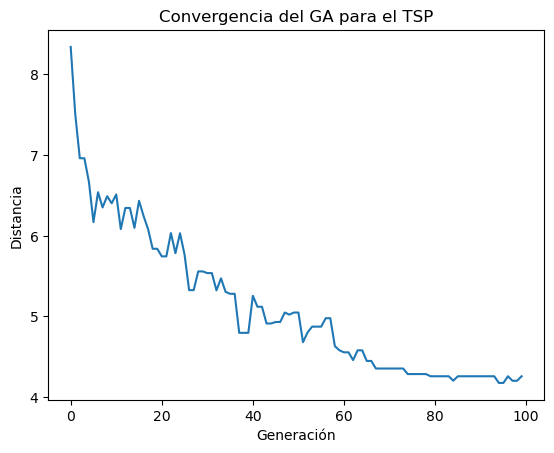

In [5]:

hist = ejecutar_ga_tsp(ciudades, 80, 0.8, 0.05, 100)
plt.plot(hist)
plt.xlabel("Generación")
plt.ylabel("Distancia")
plt.title("Convergencia del GA para el TSP")
plt.show()


## GA Externo (Hiperparámetros)

In [6]:

def crear_individuo_hp():
    return {
        "tam_pob": random.randint(5, 50),
        "p_cruce": random.uniform(0.01, 0.95),
        "p_mut": random.uniform(0.01, 0.9),
        "generaciones": random.randint(5, 100)
    }

def fitness_hp(ind, ciudades):
    hist = ejecutar_ga_tsp(
        ciudades,
        ind["tam_pob"],
        ind["p_cruce"],
        ind["p_mut"],
        ind["generaciones"]
    )
    return min(hist)


## Ejecución del Meta-GA

In [7]:
tamano_poblacion_hyper = 5
generaciones_hiper = 10
mu = 1

poblacion = [crear_individuo_hp() for _ in range(tamano_poblacion_hyper)]
resultados = []

for gen in range(generaciones_hiper):
    poblacion.sort(key=lambda ind: fitness_hp(ind, ciudades))
    mejor = poblacion[0]
    resultados.append((mejor, fitness_hp(mejor, ciudades)))
    nueva_poblacion = poblacion[:mu]
    while len(nueva_poblacion) < tamano_poblacion_hyper:
        p1 = random.choice(poblacion)
        p2 = random.choice(poblacion)
        hijo = {
            "tam_pob" : abs(int((p1["tam_pob"] + p2["tam_pob"])/2) + int(random.uniform(-10,10))),
            "p_cruce": abs(((p1["p_cruce"] + p2["p_cruce"]) / 2) + random.uniform(-0.5,0.5)),
            "p_mut": abs(((p1["p_mut"] + p2["p_mut"]) / 2) + random.uniform(-0.5,0.5)),
            "generaciones": abs(int((p1["generaciones"] + p2["generaciones"]) / 2) + int(random.uniform(-10,10))),
        }

        nueva_poblacion.append(hijo)
    poblacion = nueva_poblacion
    print("Generación " + str(gen) + " finalizada")

resultados


Generación 0 finalizada
Generación 1 finalizada
Generación 2 finalizada
Generación 3 finalizada
Generación 4 finalizada
Generación 5 finalizada
Generación 6 finalizada
Generación 7 finalizada
Generación 8 finalizada
Generación 9 finalizada


[({'tam_pob': 38,
   'p_cruce': 0.6979160788434146,
   'p_mut': 0.02609332461569363,
   'generaciones': 60},
  np.float64(4.691540002643637)),
 ({'tam_pob': 38,
   'p_cruce': 0.6979160788434146,
   'p_mut': 0.02609332461569363,
   'generaciones': 60},
  np.float64(4.509540537160464)),
 ({'tam_pob': 19,
   'p_cruce': 0.8535833496961647,
   'p_mut': 0.33490887543034054,
   'generaciones': 66},
  np.float64(5.742152347420999)),
 ({'tam_pob': 23,
   'p_cruce': 1.2714999765633666,
   'p_mut': 0.1304399880693037,
   'generaciones': 62},
  np.float64(5.63883161275626)),
 ({'tam_pob': 25,
   'p_cruce': 0.7303901097846248,
   'p_mut': 0.017414341873600858,
   'generaciones': 57},
  np.float64(4.679523059683318)),
 ({'tam_pob': 25,
   'p_cruce': 0.7303901097846248,
   'p_mut': 0.017414341873600858,
   'generaciones': 57},
  np.float64(4.592137175031178)),
 ({'tam_pob': 25,
   'p_cruce': 0.7303901097846248,
   'p_mut': 0.017414341873600858,
   'generaciones': 57},
  np.float64(5.177003521967083))

## Visualización efecto de hiperparámetros

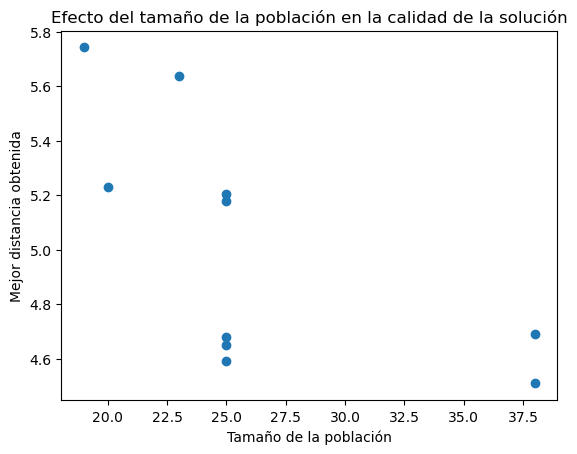

In [8]:

mut = [r[0]["tam_pob"] for r in resultados]
dist = [r[1] for r in resultados]

plt.scatter(mut, dist)
plt.xlabel("Tamaño de la población")
plt.ylabel("Mejor distancia obtenida")
plt.title("Efecto del tamaño de la población en la calidad de la solución")
plt.show()


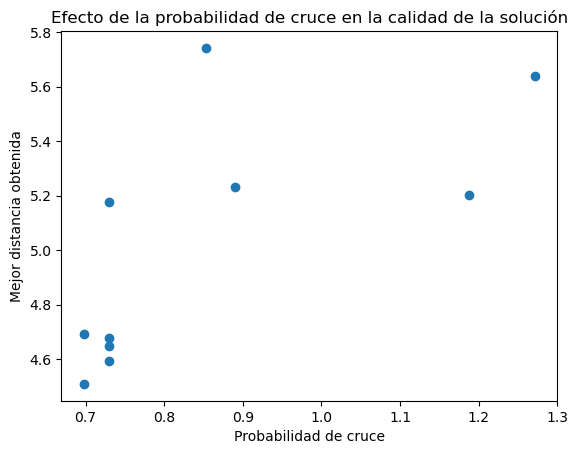

In [9]:

mut = [r[0]["p_cruce"] for r in resultados]
dist = [r[1] for r in resultados]

plt.scatter(mut, dist)
plt.xlabel("Probabilidad de cruce")
plt.ylabel("Mejor distancia obtenida")
plt.title("Efecto de la probabilidad de cruce en la calidad de la solución")
plt.show()


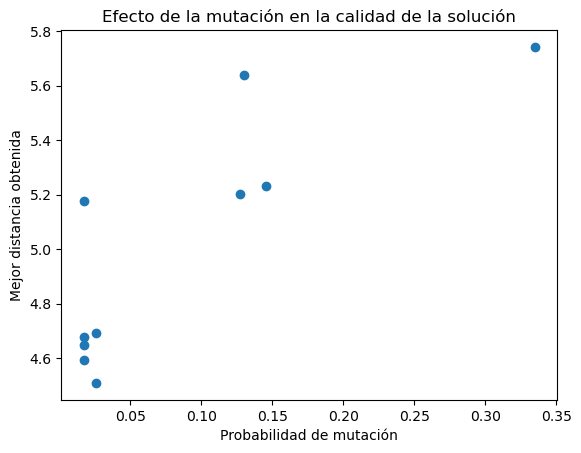

In [10]:

mut = [r[0]["p_mut"] for r in resultados]
dist = [r[1] for r in resultados]

plt.scatter(mut, dist)
plt.xlabel("Probabilidad de mutación")
plt.ylabel("Mejor distancia obtenida")
plt.title("Efecto de la mutación en la calidad de la solución")
plt.show()


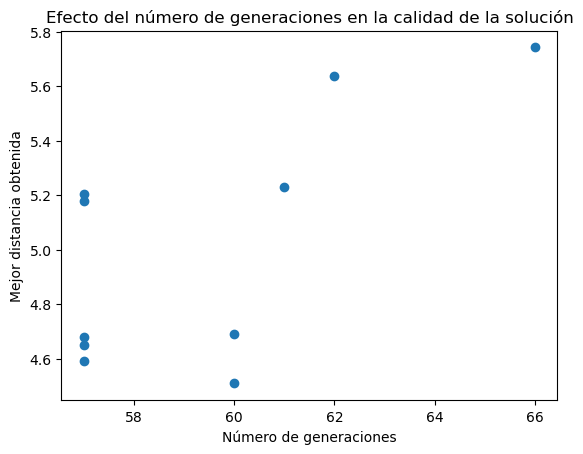

In [11]:

mut = [r[0]["generaciones"] for r in resultados]
dist = [r[1] for r in resultados]

plt.scatter(mut, dist)
plt.xlabel("Número de generaciones")
plt.ylabel("Mejor distancia obtenida")
plt.title("Efecto del número de generaciones en la calidad de la solución")
plt.show()


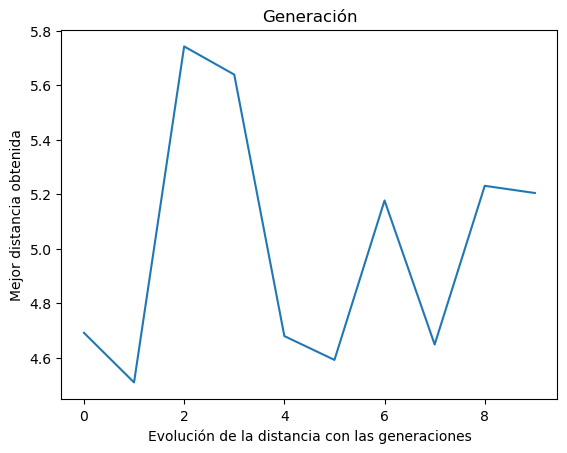

In [12]:

dist = [r[1] for r in resultados]

plt.plot(dist)
plt.xlabel("Evolución de la distancia con las generaciones")
plt.ylabel("Mejor distancia obtenida")
plt.title("Generación")
plt.show()
